In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [3]:
# Load processed data
df_roman = pd.read_csv('../data/processed/rufnd_features.csv')

# Load TF-IDF vectorizer
with open('../models/tfidf_roman.pkl', 'rb') as f:
    tfidf_roman = pickle.load(f)

# Transform text to features
X = tfidf_roman.transform(df_roman['text'])
y = df_roman['label']

print("Data loaded.")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Data loaded.
X shape: (3800, 5000)
y distribution:
label
fake    2000
real    1800
Name: count, dtype: int64


In [4]:
# Train test split - 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set: 3040 rows
Test set: 760 rows

Training label distribution:
label
fake    1600
real    1440
Name: count, dtype: int64

Test label distribution:
label
fake    400
real    360
Name: count, dtype: int64


In [5]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'Naive Bayes': MultinomialNB()
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, pos_label='fake', average='binary')
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'f1_fake': round(f1, 4)
    }
    print(f"{name} - F1 (fake class): {f1:.4f}")

Logistic Regression - F1 (fake class): 0.9440
Linear SVM - F1 (fake class): 0.9537
Random Forest - F1 (fake class): 0.9195
Naive Bayes - F1 (fake class): 0.9407


In [6]:
for name, result in results.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, result['predictions']))


Logistic Regression
              precision    recall  f1-score   support

        fake       0.96      0.93      0.94       400
        real       0.92      0.96      0.94       360

    accuracy                           0.94       760
   macro avg       0.94      0.94      0.94       760
weighted avg       0.94      0.94      0.94       760


Linear SVM
              precision    recall  f1-score   support

        fake       0.95      0.95      0.95       400
        real       0.95      0.95      0.95       360

    accuracy                           0.95       760
   macro avg       0.95      0.95      0.95       760
weighted avg       0.95      0.95      0.95       760


Random Forest
              precision    recall  f1-score   support

        fake       0.91      0.93      0.92       400
        real       0.92      0.90      0.91       360

    accuracy                           0.91       760
   macro avg       0.91      0.91      0.91       760
weighted avg       0.91   

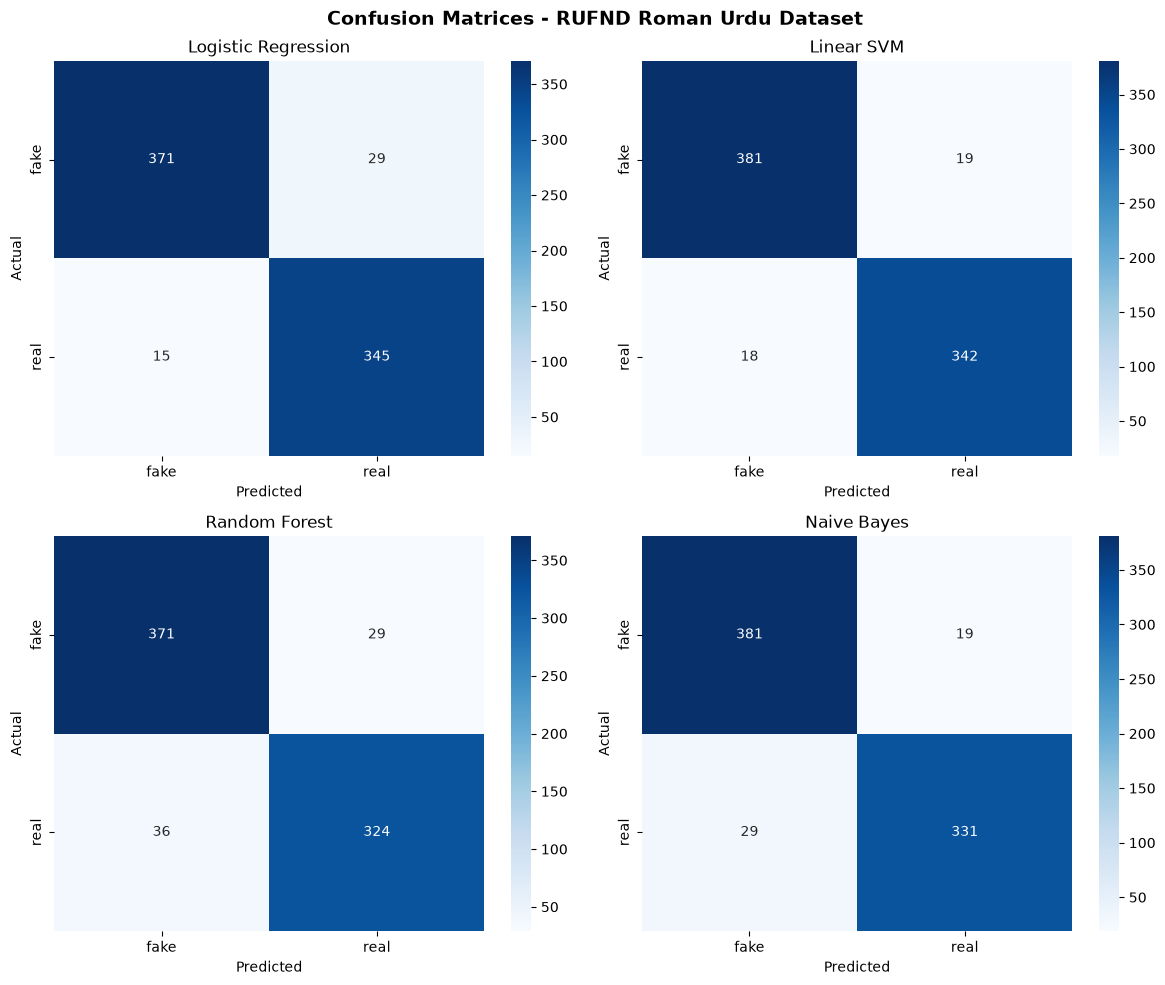

Saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'], labels=['fake', 'real'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['fake', 'real'],
        yticklabels=['fake', 'real'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - RUFND Roman Urdu Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices_roman_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

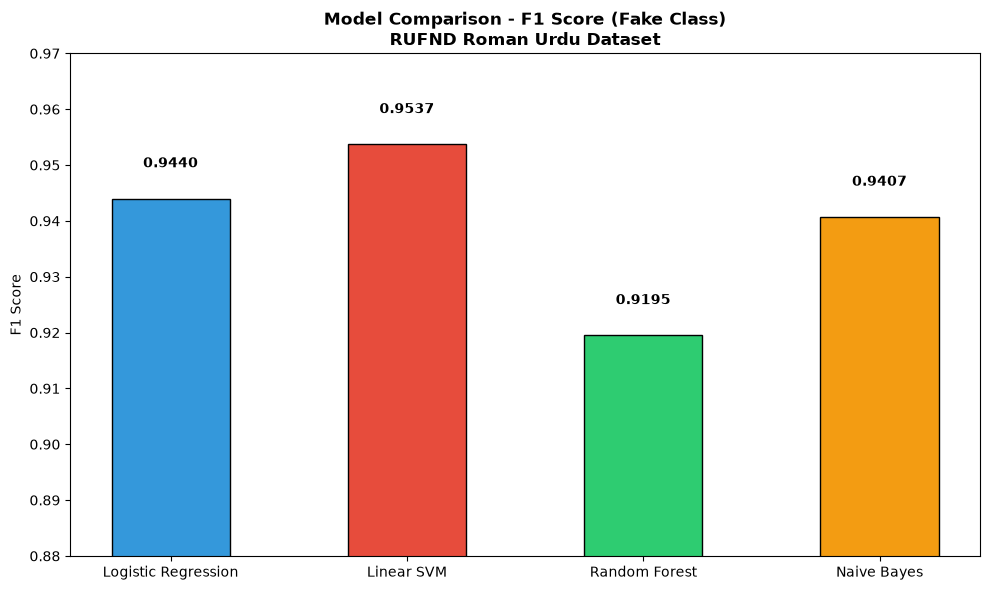

Saved.


In [8]:
# Model comparison bar chart
model_names = list(results.keys())
f1_scores = [results[name]['f1_fake'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
               edgecolor='black', width=0.5)

for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Comparison - F1 Score (Fake Class)\nRUFND Roman Urdu Dataset', fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0.88, 0.97)
plt.tight_layout()
plt.savefig('../results/figures/model_comparison_roman_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [9]:
# Save best model - Linear SVM
best_model = results['Linear SVM']['model']

with open('../models/best_model_roman_urdu.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved: Linear SVM")
print(f"F1 Score (fake class): {results['Linear SVM']['f1_fake']}")
print(f"\nModel saved to: ../models/best_model_roman_urdu.pkl")

# Summary table
summary = pd.DataFrame({
    'Model': model_names,
    'F1 (fake)': f1_scores,
    'Accuracy': [
        round((results[name]['predictions'] == y_test).mean(), 4)
        for name in model_names
    ]
})
summary = summary.sort_values('F1 (fake)', ascending=False).reset_index(drop=True)
print("\nFinal Model Summary:")
print(summary)

Best model saved: Linear SVM
F1 Score (fake class): 0.9537

Model saved to: ../models/best_model_roman_urdu.pkl

Final Model Summary:
                 Model  F1 (fake)  Accuracy
0           Linear SVM     0.9537    0.9513
1  Logistic Regression     0.9440    0.9421
2          Naive Bayes     0.9407    0.9368
3        Random Forest     0.9195    0.9145
